# Toturial 1: Fine-tuning CellFM for Cell Type Annotation
In this tutorial, we will demonstrate how to fine-tune a pre-trained CellFM model to perform cell type annotation on a new single-cell dataset. The workflow consists of the following stages:

1. Data Preprocessing

2. Data Loading

3. Model construct

4. Weight Loading

5. Fine-tuning

6. Result Visualization

Before starting, import the following packages and set up the configuration:

In [1]:
import os
os.chdir("..")
print("Current working directory:", os.getcwd())

import scanpy as sc
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import autocast, GradScaler
from layers.utils import *
import pandas as pd
import numpy as np
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

from model import Cell_FM

cfg = Config_80M()
cfg.ecs_threshold = 0.8
cfg.ecs = True
cfg.add_zero = True
cfg.pad_zero = True
cfg.use_bs = 8
cfg.mask_ratio = 0.5
### Main param ###
cfg.dataset = "HumanPBMC"
cfg.feature_col = "cell_type"
cfg.ckpt_path = "/F00120250015/cell_datasets/xiaoqianCHENG/CellFM-torch/weights/CellFM_80M_weight.ckpt"
cfg.device = "cuda:0"
cfg.epoch = 5
cfg.num_cls = 1 # by default


Current working directory: /F00120250015/cell_datasets/xiaoqianCHENG/CellFM-torch


[WARNING] ME(6201,7f25fd594740,python):2025-11-07-02:48:04.481.025 [mindspore/ccsrc/runtime/hardware_abstract/device_context/device_context_manager.cc:602] SelectGpuPlugin] Env CUDA_HOME is /usr/local/cuda, but can not find suitable gpu plugin.


# Data Preprocessing

The data preprocessing workflow is identical to the original CellFM implementation. Please follow the same steps as described in the original [CellFM documentation](https://github.com/biomed-AI/CellFM/blob/main/tutorials/process.ipynb) to prepare your datasets.

# Load Data
Load an .h5ad single-cell dataset and return a PyTorch DataLoader ready for model training or testing.

In [27]:
# === 从单个 h5ad 文件构建训练/验证集 DataLoader 的函数，测试和训练是cross batch === #

from matplotlib.pylab import f


def build_train_val_loaders_from_one_h5ad(h5_path, train_batch="batch1", test_batch="batch2"):
    # 读一次全量
    ad = read_h5ad(h5_path)
    # 统一字段
    ad.obs['celltype'] = ad.obs['cell_type'].astype(str)
    ad.obs['batch'] = ad.obs['batch'].astype(str)

    # —— 按 batch 划分 —— #
    ad_train = ad[ad.obs['batch'] == train_batch].copy()
    ad_test   = ad[ad.obs['batch'] == test_batch].copy()

    # —— 用训练集建立 label 映射；验证集复用 —— #
    uniq = pd.Index(ad_train.obs['celltype']).unique()
    print("Training set cell type distribution:")
    print(f"{ad_train.obs['celltype'].value_counts()}")
    
    label2id = {lab: i for i, lab in enumerate(uniq)}
    id2label = {i: lab for lab, i in label2id.items()}

    ad_train.obs['feat'] = ad_train.obs['celltype'].map(label2id).astype(int)
    ad_test.obs['feat']   = ad_test.obs['celltype'].map(label2id).fillna(-1).astype(int)
    
    print("ad_train.obs['feat']:")
    print(ad_train.obs['feat'].unique())
    print("ad_train.obs.head():")
    print(ad_train.obs.head())
    print("ad_train.X.shape",ad_train.X.shape)
    # 过滤验证集中训练未见过的类别（如果有）
    ad_test = ad_test[ad_test.obs['feat'] >= 0].copy()

    # —— batch id（如需） —— #
    for _ad in (ad_train, ad_test):
        _ad.obs['batch_id'] = _ad.obs['batch'].astype('category').cat.codes.astype(int)

    # —— 给 SCrna 的 train/test 标记 —— #
    ad_train.obs['train'] = 0
    ad_test.obs['train']   = 2

    # —— 告诉 cfg 类别数（在建模型之前设置！）—— #
    cfg.num_cls = len(label2id)
    cfg.label2id = label2id
    cfg.id2label = id2label

    # —— 构建 DataLoader -—— #
    ds_train = SCrna(ad_train, mode="train")
    ds_test   = SCrna(ad_test,   mode="test")

    prep_train = Prepare(cfg.nonz_len, pad=0, mask_ratio=cfg.mask_ratio)
    prep_test   = Prepare(cfg.nonz_len, pad=0, mask_ratio=cfg.mask_ratio)

    train_loader = build_dataset(
        ds_train, prep=prep_train, batch_size=cfg.use_bs,
        pad_zero=cfg.pad_zero, drop=True, shuffle=True
    )
    test_loader = build_dataset(
        ds_test, prep=prep_test, batch_size=cfg.use_bs,
        drop=True, shuffle=True
    )
    return train_loader, test_loader

human_pbmc_path = "/F00120250015/cell_datasets/xiaoqianCHENG/CellFM-torch/data/HumanPBMC.h5ad"
train_loader, test_loader = build_train_val_loaders_from_one_h5ad(
    human_pbmc_path, train_batch="batch1", test_batch="batch2"
)
print(f"\nTrain samples: {len(train_loader.dataset)}, Test samples: {len(test_loader.dataset)}")
print(f"\nNumber of classes: {cfg.num_cls}, Class mapping: {cfg.label2id}")


origin shape: (15476, 33694)
Training set cell type distribution:
celltype
CD4 T cell                     2267
CD8 T cell                     2076
Monocyte_CD14                  1914
B cell                         1199
NK cell                         303
Monocyte_FCGR3A                 206
Plasmacytoid dendritic cell      67
Megakaryocyte                    49
Hematopoietic stem cell          17
Name: count, dtype: int64
ad_train.obs['feat']:
[0 1 2 3 4 5 6 7 8]
ad_train.obs.head():
                                cell_type   batch       celltype  feat
data_3p-AAACCTGAGCATCATC-0         B cell  batch1         B cell     0
data_3p-AAACCTGAGCTAGTGG-0     CD4 T cell  batch1     CD4 T cell     1
data_3p-AAACCTGCACATTAGC-0     CD4 T cell  batch1     CD4 T cell     1
data_3p-AAACCTGCACTGTTAG-0  Monocyte_CD14  batch1  Monocyte_CD14     2
data_3p-AAACCTGCATAGTAAG-0  Monocyte_CD14  batch1  Monocyte_CD14     2
ad_train.X.shape (8098, 33694)

Train samples: 8098, Test samples: 7378

Number of cla

# Model construct
To make CellFM more flexible and reusable across different tasks, we retain its core masked recovery module and re-implement it in PyTorch as a class called `Cell_FM`. This class can either:

- Load a set of pre-trained weights and the corresponding configuration, or

- Be trained from scratch.

`Cell_FM` allows fine-tuning on new datasets to perform masked expression recovery and outputs a cls_token representing each cell.

For tasks that require cell type classification, we can simply add a linear classification layer on top of the cls_token. In this tutorial, we use a single hidden-layer linear model for this purpose.

Below, we demonstrate how to leverage the `Cell_FM` module to build a custom PyTorch model suitable for task-specific fine-tuning:

In [23]:
class Finetune_Cell_FM(nn.Module):
    def __init__(self, cfg):
        super(Finetune_Cell_FM, self).__init__()
        self.cfg = cfg
        self.num_cls = cfg.num_cls
        self.extractor = Cell_FM(27855, self.cfg, ckpt_path=self.cfg.ckpt_path, device=self.cfg.device) # n_gene, cfg=config_80M()
        # notion: 27855 is the orignal pre_train gene set of 80M CellFM model
        
        # 训练分类头
        self.cls = nn.Sequential(
            nn.Linear(self.cfg.enc_dims, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            nn.Linear(128, self.num_cls)
        )
    
    def forward(self, raw_nzdata,
                dw_nzdata,
                ST_feat,
                nonz_gene,
                mask_gene,
                zero_idx):
        
        mask_loss, cls_token = self.extractor(
                raw_nzdata,
                dw_nzdata,
                ST_feat,
                nonz_gene,
                mask_gene,
                zero_idx
            )
        
        cls = self.cls(cls_token)

        return cls, mask_loss, cls_token

# Weight Loading

You can easily load pre-trained weights using the `load_model` function in the `Cell_FM` module. Setting the option to False will initialize the model from scratch.

Note: During fine-tuning, we only unfreeze the `cls.` and `encoder` layers. This strategy reduces the computational cost and memory usage while still allowing effective adaptation to the new dataset.

In [24]:
net = Finetune_Cell_FM(cfg) # 27855

for name, param in net.named_parameters():
    param.requires_grad = "cls." in name or "encoder" in name

print("Trainable parameters:")
for name, param in net.named_parameters():
    if param.requires_grad:
        print(name)
net = net.to(cfg.device)
net.extractor.load_model(weight=True, moment=False)

optimizer = AdamW([p for p in net.parameters() if p.requires_grad], 
                    lr=1e-4,
                    weight_decay=1e-5)

scaler = GradScaler() 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)

criterion_cls = nn.CrossEntropyLoss()


Trainable parameters:
extractor.net.encoder.0.attn.q_proj.weight
extractor.net.encoder.0.attn.k_proj.weight
extractor.net.encoder.0.attn.v_proj.weight
extractor.net.encoder.0.attn.u_proj.weight
extractor.net.encoder.0.attn.o_proj.weight
extractor.net.encoder.0.ffn.u_proj.weight
extractor.net.encoder.0.ffn.v_proj.weight
extractor.net.encoder.0.ffn.o_proj.weight
extractor.net.encoder.0.post_norm1.weight
extractor.net.encoder.0.post_norm1.bias
extractor.net.encoder.0.post_norm2.weight
extractor.net.encoder.0.post_norm2.bias
extractor.net.encoder.1.attn.q_proj.weight
extractor.net.encoder.1.attn.k_proj.weight
extractor.net.encoder.1.attn.v_proj.weight
extractor.net.encoder.1.attn.u_proj.weight
extractor.net.encoder.1.attn.o_proj.weight
extractor.net.encoder.1.ffn.u_proj.weight
extractor.net.encoder.1.ffn.v_proj.weight
extractor.net.encoder.1.ffn.o_proj.weight
extractor.net.encoder.1.post_norm1.weight
extractor.net.encoder.1.post_norm1.bias
extractor.net.encoder.1.post_norm2.weight
extracto

# Fine-tuning

In [29]:
#### A lots of Path ####
from enum import unique


PT_PATH = f"../data_pt/{cfg.dataset}"
MODEL_PATH = f"../model_checkpoint/{cfg.dataset}" # for 40000 cells

#### Make dir ####
os.makedirs(PT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

#### save emb adata ####
def save_emb(emb, pred, label, save_path, mode):
    emb = np.vstack([np.atleast_2d(x) for x in emb])
    pred = np.concatenate([np.ravel(x) for x in pred])
    label = np.concatenate([np.ravel(x) for x in label])
    print("len(unique(label))",len(np.unique(label)))
    
    adata = sc.AnnData(
        X = emb,
        obs = pd.DataFrame({"pred": pred,
                          "label": label})
    )
    os.makedirs(save_path, exist_ok=True)
    sc.write(f"{save_path}/{mode}.h5ad", adata)

for epoch in range(cfg.epoch):
    train_emb, train_pred, train_label = [], [], []
    test_emb, test_pred, test_label = [], [], []
    net.train()
    print("training...")
    running_loss = 0.0
    running_acc = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epoch}")
    
    for step, batch in enumerate(progress):    
        raw_nzdata = batch['raw_nzdata'].to(cfg.device)
        dw_nzdata = batch['dw_nzdata'].to(cfg.device)
        ST_feat = batch['ST_feat'].to(cfg.device)
        nonz_gene = batch['nonz_gene'].to(cfg.device)
        mask_gene = batch['mask_gene'].to(cfg.device)
        zero_idx = batch['zero_idx'].to(cfg.device)
        celltype_label = batch['celltype_label'].to(cfg.device)
        batch_id = batch['batch_id'].to(cfg.device)
        feat = batch['feat'].long().to(cfg.device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            cls, mask_loss, cls_token = net(
                raw_nzdata=raw_nzdata,
                dw_nzdata=dw_nzdata,
                ST_feat=ST_feat,
                nonz_gene=nonz_gene,
                mask_gene=mask_gene,
                zero_idx=zero_idx
            ) 
            
            cls_loss = criterion_cls(cls, feat)
            loss = mask_loss + cls_loss
        
        scaler.scale(loss).backward()
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        pred = cls.argmax(1)
        accuracy = (pred == feat).sum().item()
        accuracy = accuracy / len(batch_id)
        
        running_loss += loss.item()
        running_acc += accuracy
        
        avg_loss = running_loss / (step + 1)
        avg_acc = running_acc / (step + 1)
        
        progress.set_postfix(loss=avg_loss, acc=avg_acc)
        
        train_emb.append(cls_token.detach().cpu().numpy().tolist())
        train_label.append(feat.detach().cpu().numpy().tolist())
        train_pred.append(pred.detach().cpu().numpy().tolist())
    
    scheduler.step()
    print(f"Epoch {epoch+1} complete,avg loss: {avg_loss:.6f}")
    torch.save(net.state_dict(), f"{MODEL_PATH}/checkpoint_epoch_{epoch+1}.pth")
    
    # save adata train
    save_emb_pth = f"{PT_PATH}/epoch_{epoch}"
    save_emb(train_emb, train_pred, train_label, save_emb_pth, 'train')
    
    net.eval()
    print("testing...")
    running_loss = 0.0
    running_acc = 0.0

    progress = tqdm(test_loader, desc="Testing")
    with torch.no_grad(): 
        for step, batch in enumerate(progress):    
            
            raw_nzdata = batch['raw_nzdata'].to(cfg.device)
            dw_nzdata = batch['dw_nzdata'].to(cfg.device)
            ST_feat = batch['ST_feat'].to(cfg.device)
            nonz_gene = batch['nonz_gene'].to(cfg.device)
            mask_gene = batch['mask_gene'].to(cfg.device)
            zero_idx = batch['zero_idx'].to(cfg.device)
            celltype_label = batch['celltype_label'].to(cfg.device)
            batch_id = batch['batch_id'].to(cfg.device)
            feat = batch['feat'].long().to(cfg.device)

            with torch.cuda.amp.autocast():
                cls, mask_loss, cls_token = net(
                    raw_nzdata=raw_nzdata,
                    dw_nzdata=dw_nzdata,
                    ST_feat=ST_feat,
                    nonz_gene=nonz_gene,
                    mask_gene=mask_gene,
                    zero_idx=zero_idx
                ) 
                
                cls_loss = criterion_cls(cls, feat)
                loss = mask_loss[0] + cls_loss

            pred = cls.argmax(1)
            accuracy = (pred == feat).sum().item()
            accuracy = accuracy / len(batch_id)
            
            running_loss += loss.item()
            running_acc += accuracy
            
            avg_loss = running_loss / (step + 1)
            avg_acc = running_acc / (step + 1)
            
            progress.set_postfix(loss=avg_loss, acc=avg_acc)
            
            test_emb.append(cls_token.detach().cpu().numpy().tolist())
            test_label.append(feat.detach().cpu().numpy().tolist())
            test_pred.append(pred.detach().cpu().numpy().tolist())
    
    print(f"Testing {epoch+1} complete,avg loss: {avg_loss:.6f}, avg acc: {avg_acc:.6f}")
    
    # save adata train
    save_emb_pth = f"{PT_PATH}/epoch_{epoch}"
    save_emb(test_emb, test_pred, test_label, save_emb_pth, 'test')

training...


Epoch 1/5: 100%|██████████| 1012/1012 [02:14<00:00,  7.53it/s, acc=0.869, loss=16] 


Epoch 1 complete,avg loss: 15.988758
len(unique(label)) 9
testing...


Testing: 100%|██████████| 922/922 [00:46<00:00, 19.93it/s, acc=0.877, loss=12.9]


Testing 1 complete,avg loss: 12.906181, avg acc: 0.877169
len(unique(label)) 9
training...


...

Testing 4 complete,avg loss: 12.892018, avg acc: 0.888964
len(unique(label)) 9
training...


Epoch 5/5: 100%|██████████| 1012/1012 [02:14<00:00,  7.53it/s, acc=0.912, loss=15.9]


Epoch 5 complete,avg loss: 15.882375
len(unique(label)) 9
testing...


Testing: 100%|██████████| 922/922 [00:46<00:00, 19.93it/s, acc=0.882, loss=12.9]


Testing 5 complete,avg loss: 12.899071, avg acc: 0.881508
len(unique(label)) 9


# Result Visualization
During fine-tuning, we observed that the highest test PCC (0.982527) was achieved at the 4th epoch. To further evaluate the effectiveness of the model, we visualize the fine-tuned cell embeddings using UMAP, which provides an intuitive view of how well the embeddings capture the underlying cell type structure.

In [31]:
import scanpy as sc
emb_train = sc.read(f"../data_pt/{cfg.dataset}/epoch_2/train.h5ad")
emb_test = sc.read(f"../data_pt/{cfg.dataset}/epoch_2/test.h5ad")

In [32]:
def plot_umap(adata):
    adata.obs["pred"] = adata.obs["pred"].astype('category')
    adata.obs["label"] = adata.obs["label"].astype('category')
    
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.pl.umap(adata, color="pred")
    sc.pl.umap(adata, color="label")

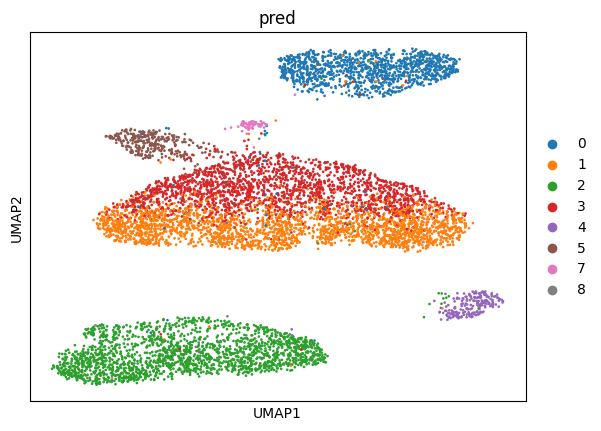

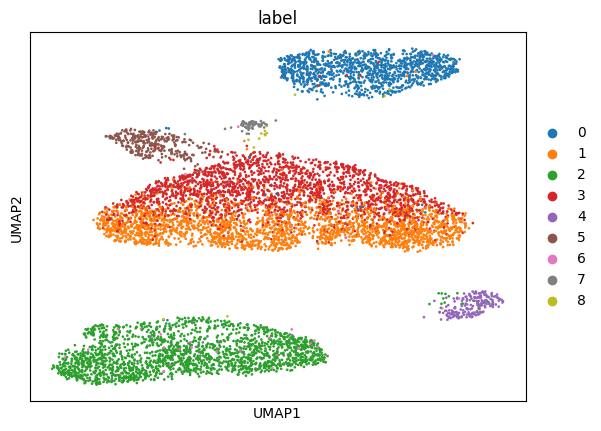

In [33]:
plot_umap(emb_train)

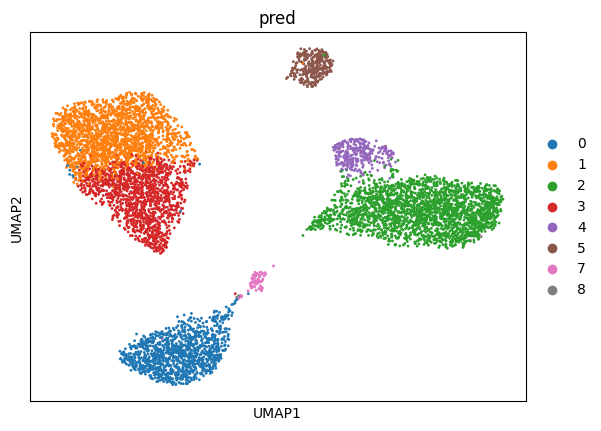

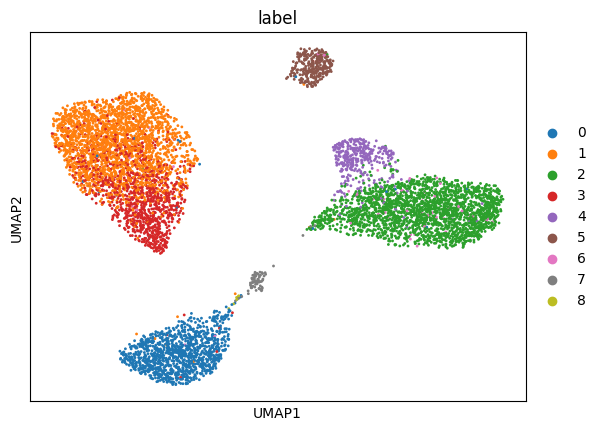

In [35]:
plot_umap(emb_test)